In [31]:
import numpy as np
from surmof_cavity import ag_surmof_cavity_trref as transmission
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial
import contourint
import functools
from tqdm import tqdm
import warnings

In [32]:
material_poles = np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])/300*2*np.pi

damping = np.array([6.2, 6.0, 5.3])
gamma_half = damping*np.pi/300

material_poles = np.sqrt(material_poles**2-gamma_half**2)-1j*gamma_half

In [33]:
pad_r = 0.02
pad_i = 0.002j
radius_r = 0.08
radius_i = 0.01j
#punchout = 0.3
punchout = 0.6
overlap = 0.55
num_recursions = 40
#num_recursions = 1
pad = 0 #0.002

integration_centers = list(material_poles[-1:]-pad)

centers = integration_centers*num_recursions
# centers = [
#     pole - pad_r - radius_r for pole in material_poles
# ]
# centers += [
#     pole - pad_i - radius_i for pole in material_poles
# ]
# centers += [
#     pole + pad_i + radius_i for pole in material_poles
# ]

num_points = [512]*len(integration_centers)*num_recursions
radii = []
for i in range(num_recursions):
    radii += [(radius_r + radius_i)*((punchout+overlap)**i)]*len(integration_centers)

# contours = [
#     contourint.Ellipse(center=center, radius=radius, num_points=nump) for 
#     center, radius, nump in zip(centers, radii, num_points)
# ]

#contour = contourint.Ellipse(center = 15-1j, radius=14+2j, num_points = 2048)

In [34]:
radii

[(0.08+0.01j),
 (0.092+0.0115j),
 (0.10579999999999999+0.013224999999999999j),
 (0.12166999999999999+0.015208749999999998j),
 (0.13992049999999995+0.017490062499999993j),
 (0.16090857499999994+0.020113571874999993j),
 (0.18504486124999994+0.023130607656249993j),
 (0.2128015904374999+0.02660019880468749j),
 (0.24472182900312486+0.030590228625390608j),
 (0.2814301033535936+0.0351787629191992j),
 (0.32364461885663254+0.04045557735707907j),
 (0.37219131168512737+0.04652391396064092j),
 (0.4280200084378965+0.05350250105473706j),
 (0.4922230097035809+0.06152787621294761j),
 (0.566056461159118+0.07075705764488975j),
 (0.6509649303329857+0.08137061629162322j),
 (0.7486096698829334+0.09357620873536668j),
 (0.8609011203653735+0.10761264004567168j),
 (0.9900362884201793+0.12375453605252242j),
 (1.1385417316832063+0.14231771646040078j),
 (1.3093229914356872+0.1636653739294609j),
 (1.50572144015104+0.18821518001888j),
 (1.7315796561736958+0.21644745702171198j),
 (1.99131660459975+0.2489145755749687

In [35]:
contours= [
    contourint.Stack(contours=[
        contourint.Ellipse(center=center, radius=np.conj(radius)*punchout, num_points=nump),
        contourint.Ellipse(center=center, radius=radius, num_points=nump)
    ]) for 
    center, radius, nump in zip(centers, radii, num_points)
]

In [36]:
ts = 0.025*(np.arange(50)+2)#[-1:]
all_poles = []
all_residues = []
npoles = 1#3
max_num_poles = 4

for thickness in tqdm(ts):
    t_poles = []
    t_residues = []
    for contour in contours:
        #functools.lru_cache(maxsize=None)()
        f = partial(transmission, thickness=thickness, npoles=npoles)
        try:
            poles, residues = contourint.locate_poles(contour, f, M=max_num_poles, cutoff=1e-12, k_factor=1)
        except ValueError:
            warnings.warn("Finding Poles failed")
            poles = residues = np.array([])
        num_found = len(poles)
        missing = (max_num_poles-num_found)

        poles = np.concatenate([poles, [np.nan]*missing])
        residues = np.concatenate([residues, [np.nan]*missing])
        
        t_poles.append(poles)
        t_residues.append(residues)
    all_poles.append(t_poles)
    all_residues.append(t_residues)

  0%|          | 0/50 [00:00<?, ?it/s]

[-0.23346004-0.10952142j  0.23346004+0.10952142j]
[ 0.23722292+0.12398008j -0.23722292-0.12398008j]
[-0.2294836-0.13366547j  0.2294836+0.13366547j]
[ 0.21768974+0.14103633j -0.21768974-0.14103633j]
[-0.20464636-0.14705814j  0.20464636+0.14705814j]
[ 0.19132744+0.15208928j -0.19132744-0.15208928j]
[-0.17806964-0.15627191j  0.17806964+0.15627191j]
[ 0.16499962+0.15967593j -0.16499962-0.15967593j]
[ 0.23722292+0.12398008j -0.23722292-0.12398008j]
[-0.2294836-0.13366547j  0.2294836+0.13366547j]
[ 0.21768974+0.14103633j -0.21768974-0.14103633j]
[-0.20464636-0.14705814j  0.20464636+0.14705814j]
[ 0.19132744+0.15208928j -0.19132744-0.15208928j]
[-0.17806964-0.15627191j  0.17806964+0.15627191j]
[ 0.16499962+0.15967593j -0.16499962-0.15967593j]
[-0.15217568-0.16234787j  0.15217569+0.16234788j]
[-0.20300873-0.09523602j  0.20300873+0.09523602j]
[ 0.17937461+0.09374675j -0.17937461-0.09374675j]
[-0.15088919-0.08788722j  0.15088919+0.08788722j]
[ 0.12446482+0.08063798j -0.12446482-0.08063798j]
[-0.

  2%|▏         | 1/50 [00:03<02:29,  3.04s/it]

[ 3.61311366+0.23824703j 47.1271382 +4.87640952j]
[ -11.83936905 -0.87369838j -190.78639656-28.12721242j]
[ 38.78765736  +3.16801801j 745.48647844+151.82619913j]
[ -127.05185958 -11.38129864j -2763.20025028-785.10755925j]
[ 416.09738601  +40.57282215j 9359.13915012+3936.99339614j]
[ -1362.50811199  -143.69024352j -26148.82953128-19277.0697251j ]
[ 0.64833082+0.02196909j -0.55914381-0.02576166j]
[-2.43619965-0.05069528j  2.01729087+0.06653047j]
[ 9.4210713 +0.42825942j -7.45363196-0.49335366j]
[-36.18454049-2.52590645j  26.94509422+2.78810297j]
[138.2407835 +12.95691242j -94.85455778-13.98419564j]
[-526.00687772-61.77119457j  322.29437701+65.63865567j]
[ 1995.19432679+281.47459199j -1038.78932281-295.15101185j]
[-7549.27515005-1243.80743642j  3059.51918985+1287.01012482j]
[-2.43619965-0.05069528j  2.01729087+0.06653047j]
[ 9.4210713 +0.42825942j -7.45363196-0.49335366j]
[-36.18454049-2.52590645j  26.94509422+2.78810297j]
[138.2407835 +12.95691242j -94.85455778-13.98419564j]
[-526.006877

  4%|▍         | 2/50 [00:06<02:26,  3.05s/it]

...

[   3169.3751378   +2309.89436684j -175966.56255383-248675.46512555j]
[  11513.78588      +7957.95015509j -733860.35529812-2003056.57834241j]
[-0.08602535-0.03540061j -0.18760627-0.08765063j]
[0.35976506+0.14616045j 1.26446698+0.58875026j]
[-1.49749813-0.60048126j -8.45895259-3.92441148j]
[ 6.20517497 +2.4553355j  56.19342354+25.97264998j]
[ -25.60226289  -9.99460919j -370.88696143-170.76625535j]
[ 105.20659239  +40.51104858j 2433.43675419+1116.04940328j]
[  -430.68171461 -163.54883022j -15880.23313284-7254.54455627j]
[  1756.83051184  +657.81419304j 103129.46238572+46927.18822646j]
[0.35976506+0.14616045j 1.26446698+0.58875026j]
[-1.49749813-0.60048126j -8.45895259-3.92441148j]
[ 6.20517497 +2.4553355j  56.19342354+25.97264998j]
[ -25.60226289  -9.99460919j -370.88696143-170.76625535j]
[ 105.20659239  +40.51104858j 2433.43675419+1116.04940328j]
[  -430.68171461 -163.54883022j -15880.23313284-7254.54455627j]
[  1756.83051184  +657.81419304j 103129.46238572+46927.18822646j]
[  -7142.902

 98%|█████████▊| 49/50 [02:35<00:03,  3.05s/it]

[-0.09048445-0.03759991j -0.19712071-0.09306995j]
[0.39467555+0.1619616j  1.38788482+0.65319675j]
[-1.71337036-0.69419421j -9.69835353-4.54906195j]
[ 7.40446175 +2.96132387j 67.29455047+31.45409101j]
[ -31.86133259 -12.57562695j -463.90555807-216.05227359j]
[ 136.54228463  +53.17682247j 3178.96206046+1475.10020465j]
[  -582.9249858   -223.96429516j -21666.36000817-10016.54195458j]
[  2479.77571125  +939.75674736j 146948.37049719+67685.01658069j]
[0.39467555+0.1619616j  1.38788482+0.65319675j]
[-1.71337036-0.69419421j -9.69835353-4.54906195j]
[ 7.40446175 +2.96132387j 67.29455047+31.45409101j]
[ -31.86133259 -12.57562695j -463.90555807-216.05227359j]
[ 136.54228463  +53.17682247j 3178.96206046+1475.10020465j]
[  -582.9249858   -223.96429516j -21666.36000817-10016.54195458j]
[  2479.77571125  +939.75674736j 146948.37049719+67685.01658069j]
[ -10514.25825205  -3929.60307045j -992305.45417954-455384.6786815j ]
[0.10030372+0.04331081j 0.23126176+0.11498109j]
[-0.44054205-0.18839201j -1.7136

100%|██████████| 50/50 [02:38<00:00,  3.18s/it]

[-61.69950976  -88.00391256j 543.15926022+1170.71802228j]
[-253.59872517 -353.06917758j 2931.43011165+9000.48432574j]
[-1106.73507268 -1394.24941017j 29256.33292054+55637.89310298j]
[ -4502.5637102   -5503.19468215j 160879.65474538+426416.24088069j]
[ -19134.83343885  -21425.64597557j 1544641.68422007+2608228.13021868j]


In [37]:
all_poles

[[array([8.5747877 -0.06570557j, 8.61179014-0.05134481j,
         8.66247919-0.08200599j, 8.71138131-0.0166961j ]),
  array([8.62184745-0.06860561j, 8.53485487-0.04895328j,
         8.65153639-0.14319475j, 8.78740362-0.02597737j]),
  array([8.57284737-0.06934746j, 8.69132875-0.02865389j,
         8.53871299-0.0623438j , 8.72740661-0.09213609j]),
  array([8.56272872-0.07467094j, 8.53435604-0.10488218j,
         8.70082995-0.04622155j, 8.75835698+0.05039355j]),
  array([8.56437574-0.07448582j, 8.70929062-0.15403512j,
         8.73168691+0.05548358j, 9.07200857-0.21322459j]),
  array([8.56437564-0.07448558j,        nan+0.j        ,
                nan+0.j        ,        nan+0.j        ]),
  array([8.56437564-0.07448558j,        nan+0.j        ,
                nan+0.j        ,        nan+0.j        ]),
  array([8.56437564-0.07448558j,        nan+0.j        ,
                nan+0.j        ,        nan+0.j        ]),
  array([8.56437564-0.07448558j,        nan+0.j        ,
               

In [38]:
wfreqr1 = material_poles[-1].real - np.logspace(-6, -0.8, 800) 

wfreqi = np.linspace(-0.05, -0.06, 200)

wfreqr = np.concatenate([wfreqr1 ,np.linspace(-1, 16, 200)])
wfreqr = np.sort(wfreqr)

wfreqi = np.concatenate([wfreqi, np.linspace(-1, 0.2, 200)])
wfreqi = np.sort(wfreqi)

Wfreqr, Wfreqi = np.meshgrid(wfreqr, wfreqi, indexing='ij')
Wfreq = Wfreqr + 1j*Wfreqi

In [39]:
F = f(Wfreq)

/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:39: RuntimeWarning: overflow encountered in exp
  den = 1 - m1ref_back * m2ref_fwd * np.exp(1j*k3*2*d3)
/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:39: RuntimeWarning: overflow encountered in multiply
  den = 1 - m1ref_back * m2ref_fwd * np.exp(1j*k3*2*d3)
/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:39: RuntimeWarning: invalid value encountered in multiply
  den = 1 - m1ref_back * m2ref_fwd * np.exp(1j*k3*2*d3)
/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:40: RuntimeWarning: overflow encountered in exp
  tr = m1tr_fwd * m2tr_fwd * np.exp(1j*k3*d3) / den
/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:40: RuntimeWarning: invalid value encountered in multiply
  tr = m1tr_fwd * m2tr_fwd * np.exp(1j*k3*d3) / den
/users/tfp/jdf/code/agsurmof-cavity-rse/notebooks/surmof_cavity.py:40: RuntimeWarning: invalid value encountered in divide
  tr 

In [40]:
tolerances = np.sqrt(np.abs(np.array(radii))) * 1e-3
num_shells = len(radii)
search_shells = 4
min_hits = 2
filtered_all_poles = []
for t_poles in all_poles: # poles of a given thickness
    filtered_t_poles = []
    f_t_residues = [] # TODO
    for (i, outer), tol in zip(enumerate(t_poles), tolerances):
        for reference_pole in outer: # one specific pole
            hits = 0
            for idx_inner_shell in range(min(num_shells-i, search_shells)):
                dist = np.abs(reference_pole - t_poles[i + idx_inner_shell])
                hits += np.any(dist<tol)
            if hits>min_hits:
                filtered_t_poles.append(reference_pole)
                f_t_residues = []
    filtered_all_poles.append(filtered_t_poles)

/tmp/ipykernel_3143255/1453124960.py:13: RuntimeWarning: invalid value encountered in subtract
  dist = np.abs(reference_pole - t_poles[i + idx_inner_shell])


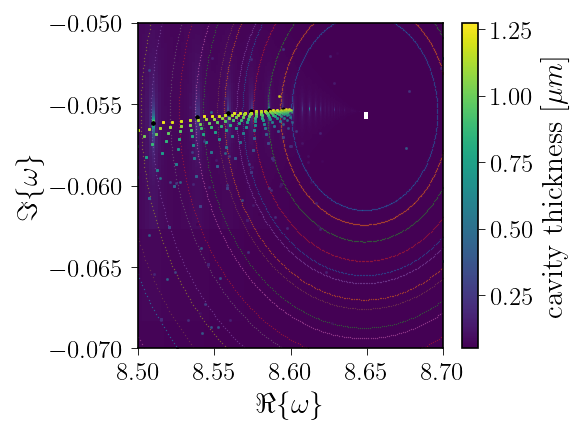

In [41]:
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(ts), vmax=max(ts))
colors = cmap(norm(ts))

plt.pcolormesh(Wfreqr, Wfreqi, np.abs(F).astype(float), alpha=1, rasterized=True, vmax=1e1)
xlim, ylim = plt.xlim(), plt.ylim()
for contour in contours:
    plt.scatter(contour.points.real, contour.points.imag, s=0.3, alpha = 0.4)

first = True
for color, t_poles in list(zip(colors, all_poles))[::-1]:
    poles = np.array(t_poles).flatten()
    s = 1.5
    if first:
        first=False
        s=3
        color="k"
    plt.scatter(poles.real, poles.imag, color=color, s=s, alpha = 0.9)

plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mu m$]")

plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")

plt.xlim(xlim)
plt.ylim(ylim)

plt.savefig("out/poles_overview.pdf", dpi=300)


plt.xlim(8, 10)
plt.ylim(-0.12, -0.05)
plt.xlim(8.5, 8.7)
plt.ylim(-0.07, -0.05)
plt.savefig("out/poles_zoom.pdf", dpi=300)

In [42]:
results = {'filtered_poles': filtered_all_poles, 'thicknesses': ts}

In [43]:
np.save("out/1pole/ag_surmof.npy", results)

In [44]:
all_results = {'all_poles': all_poles, "all_residues": all_residues}

In [45]:
np.save("out/1pole/all_ag_surmof.npy", all_results)